# Proxy Target Variable Engineering: Task 4
**Bati Bank | Buy-Now-Pay-Later Credit Scoring Project**

Objective: Construct a binary credit risk label (`is_high_risk`) from
behavioral data using RFM analysis and K-Means clustering, since the
raw dataset contains no default label.

All production logic lives in `src/data_processing.py`.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from src.data_processing import (
    load_raw_data,
    fit_transform_pipeline,
    compute_rfm,
    assign_high_risk_label,
    build_model_dataset,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

In [2]:
DATA_PATH = "../data/raw/data.csv"
df_raw = load_raw_data(DATA_PATH)
print(f"Raw data: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Raw data: 95,662 rows × 16 columns


### 1. Calculate RFM Metrics

For each customer, compute:

| Metric | Definition |
|---|---|
| **Recency** | Days since the customer's last transaction (lower = more recent = more engaged) |
| **Frequency** | Total number of transactions |
| **Monetary** | Total absolute transaction value (sum of `Value`) |

The snapshot date is set to one day after the last transaction in the dataset,
ensuring recency is calculated consistently for all customers.

In [3]:
rfm = compute_rfm(
    df_raw,
    customer_col="CustomerId",
    date_col="TransactionStartTime",
    amount_col="Value",
)

print(f"RFM computed for {len(rfm):,} customers.")
rfm.head()

RFM computed for 3,742 customers.


,CustomerId,recency,frequency,monetary
0,CustomerId_1,84,1,10000
1,CustomerId_10,84,1,10000
2,CustomerId_1001,90,5,30400
3,CustomerId_1002,26,11,4775
4,CustomerId_1003,12,6,32000


In [4]:
rfm[["recency", "frequency", "monetary"]].describe().T \
    .style.format("{:.2f}").set_caption("RFM Feature Summary Statistics")

,count,mean,std,min,25%,50%,75%,max
recency,3742.00,31.46,27.12,1.00,6.00,25.00,54.00,91.00
frequency,3742.00,25.56,96.93,1.00,2.00,7.00,20.00,4091.00
monetary,3742.00,253102.53,2715876.81,50.00,6500.00,32000.00,102060.00,104900000.00


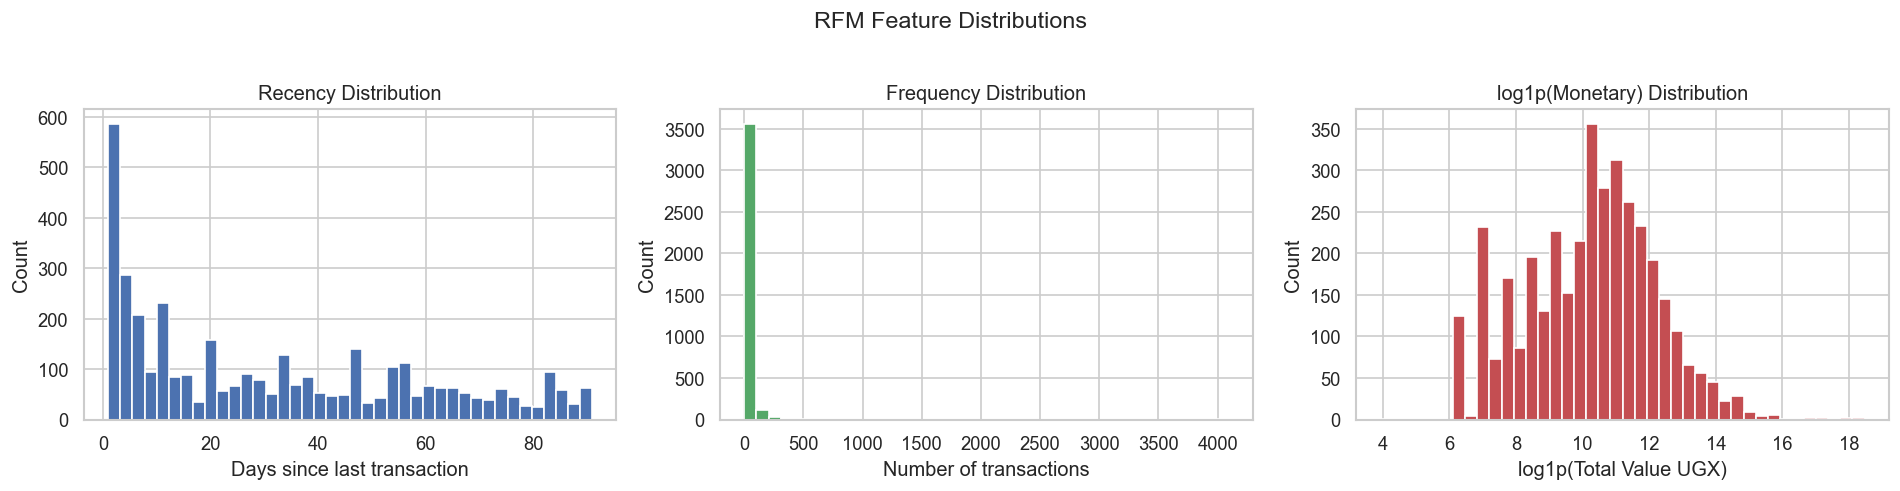

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["recency"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency Distribution", fontsize=12)
axes[0].set_xlabel("Days since last transaction")
axes[0].set_ylabel("Count")

axes[1].hist(rfm["frequency"], bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Frequency Distribution", fontsize=12)
axes[1].set_xlabel("Number of transactions")
axes[1].set_ylabel("Count")

axes[2].hist(np.log1p(rfm["monetary"]), bins=40, color="#C44E52", edgecolor="white")
axes[2].set_title("log1p(Monetary) Distribution", fontsize=12)
axes[2].set_xlabel("log1p(Total Value UGX)")
axes[2].set_ylabel("Count")

plt.suptitle("RFM Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Figure 1: RFM Feature Distributions
Recency: Most customers made a transaction recently, with a high concentration in the first few days, while fewer customers have been inactive for long periods.
Frequency: Transaction frequency is highly right-skewed; most customers transact infrequently, while a small number of customers are extremely active.
Monetary: After log transformation, monetary values appear approximately bell-shaped, indicating that spending behavior is more evenly distributed and suitable for clustering.

### 2. Cluster Customers with K-Means

RFM features are standardized (mean=0, std=1) before clustering to
ensure all three dimensions contribute equally regardless of scale.

K-Means is run with **k=3** and `random_state=42` for reproducibility.
Three clusters represent a natural segmentation:
- High-engagement customers (low recency, high frequency, high monetary)
- Medium-engagement customers
- Low-engagement / disengaged customers (high-risk proxy)

In [6]:
rfm_labeled = assign_high_risk_label(
    rfm,
    n_clusters=3,
    random_state=42,
)

print(f"Total customers      : {len(rfm_labeled):,}")
print(f"High-risk (1)        : {rfm_labeled['is_high_risk'].sum():,} "
      f"({rfm_labeled['is_high_risk'].mean()*100:.1f}%)")
print(f"Low-risk  (0)        : {(rfm_labeled['is_high_risk'] == 0).sum():,} "
      f"({(rfm_labeled['is_high_risk'] == 0).mean()*100:.1f}%)")

Total customers      : 3,742
High-risk (1)        : 1,426 (38.1%)
Low-risk  (0)        : 2,316 (61.9%)


In [7]:
cluster_profile = (
    rfm_labeled.groupby("cluster")[["recency", "frequency", "monetary", "is_high_risk"]]
    .mean()
    .round(2)
)
cluster_profile.columns = ["Mean Recency (days)", "Mean Frequency", "Mean Monetary (UGX)", "Is High Risk"]
cluster_profile.style.set_caption("Cluster Profiles — Mean RFM Values").format("{:.2f}")

,Mean Recency (days),Mean Frequency,Mean Monetary (UGX),Is High Risk
cluster,,,,
0,61.88,7.72,89737.93,1.00
1,12.72,34.70,224756.50,0.00
2,23.25,1104.50,74876587.00,0.00


### 3. Visualize the Clusters

The scatter plots below show how the three clusters separate in
RFM space. The high-risk cluster (orange) should occupy the region
of high recency (disengaged), low frequency, and low monetary value.

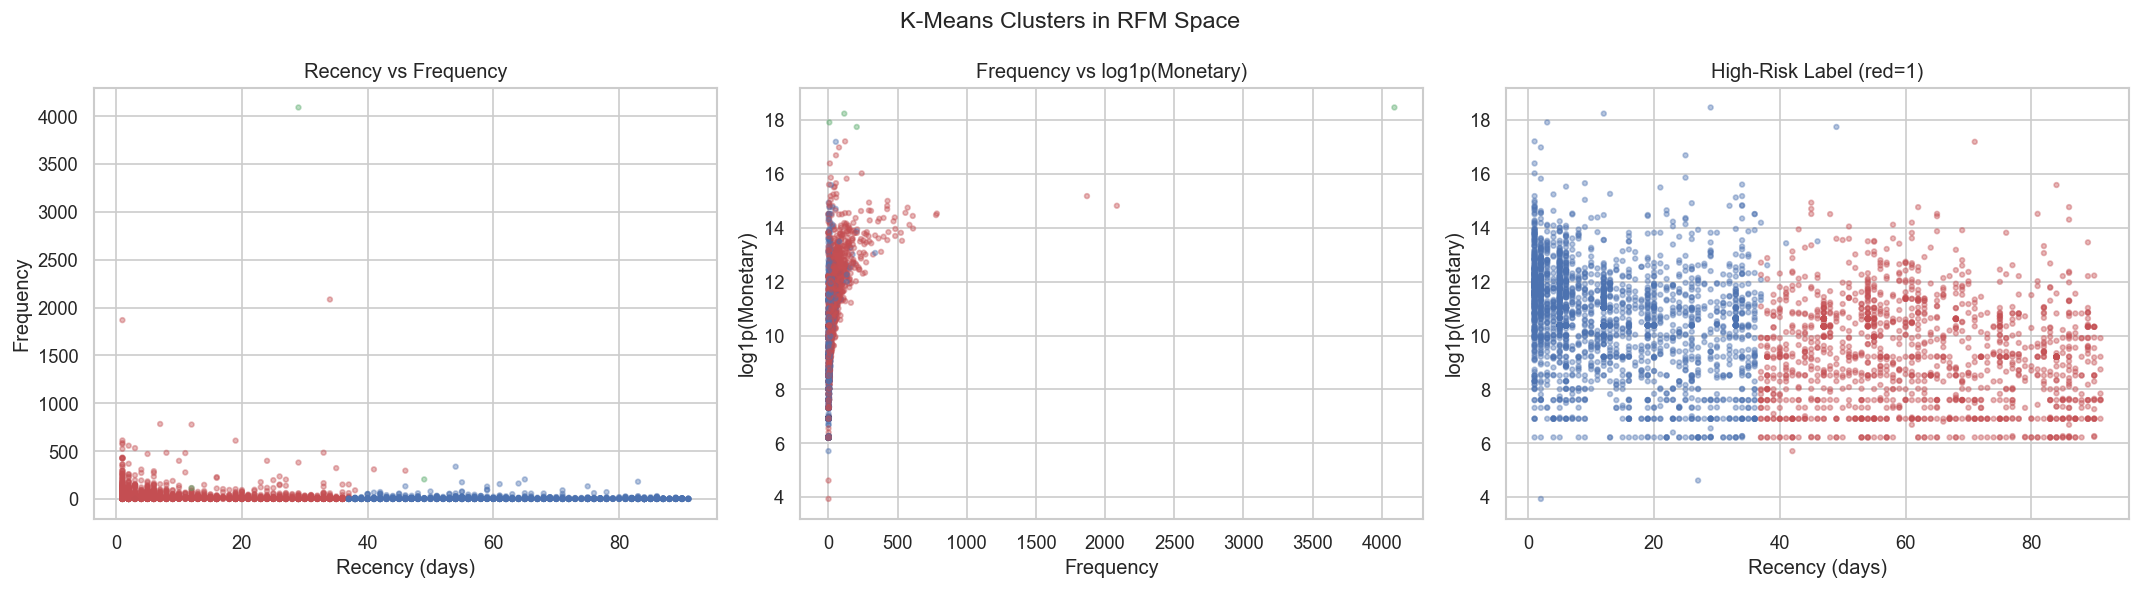

In [8]:
palette = {0: "#4C72B0", 1: "#C44E52", 2: "#55A868"}
risk_palette = {0: "#4C72B0", 1: "#C44E52"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency vs Frequency
axes[0].scatter(
    rfm_labeled["recency"], rfm_labeled["frequency"],
    c=rfm_labeled["cluster"].map(palette), alpha=0.4, s=8
)
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Recency vs Frequency", fontsize=12)

# Frequency vs Monetary
axes[1].scatter(
    rfm_labeled["frequency"], np.log1p(rfm_labeled["monetary"]),
    c=rfm_labeled["cluster"].map(palette), alpha=0.4, s=8
)
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("log1p(Monetary)")
axes[1].set_title("Frequency vs log1p(Monetary)", fontsize=12)

# Recency vs Monetary coloured by is_high_risk
axes[2].scatter(
    rfm_labeled["recency"], np.log1p(rfm_labeled["monetary"]),
    c=rfm_labeled["is_high_risk"].map(risk_palette), alpha=0.4, s=8
)
axes[2].set_xlabel("Recency (days)")
axes[2].set_ylabel("log1p(Monetary)")
axes[2].set_title("High-Risk Label (red=1)", fontsize=12)

plt.suptitle("K-Means Clusters in RFM Space", fontsize=14)
plt.tight_layout()
plt.show()

Figure 2: K-Means Clusters in RFM Space
Recency vs Frequency: Clusters are primarily separated by transaction activity, with a small group of highly active customers standing out from the majority of low-frequency users.
Frequency vs Monetary: Customers with higher transaction frequencies generally exhibit higher monetary values, suggesting a positive relationship between engagement and spending.
High-Risk Label Visualization: The high-risk segment is largely composed of customers with higher recency values (longer inactivity periods), while recently active customers are predominantly classified as low risk.

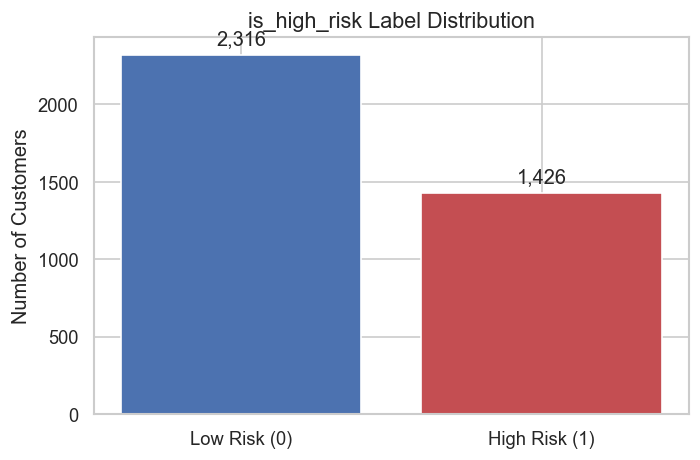

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = rfm_labeled["is_high_risk"].value_counts().sort_index()
bars = ax.bar(
    ["Low Risk (0)", "High Risk (1)"],
    counts.values,
    color=["#4C72B0", "#C44E52"],
    edgecolor="white",
)
ax.bar_label(bars, fmt="{:,.0f}", padding=4)
ax.set_title("is_high_risk Label Distribution", fontsize=13)
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Figure 3: High-Risk Label Distribution
The proxy target generation produced 2,316 low-risk customers (61.9%) and 1,426 high-risk customers (38.1%). The classes are reasonably balanced, providing sufficient representation of both groups for predictive modeling without severe class imbalance concerns.

### 4. Integrate the Target Variable

Merge `is_high_risk` into the processed feature DataFrame produced
by `fit_transform_pipeline()`. This produces the final model-ready
dataset for Tasks 5 and 6.

In [10]:
# Run the full feature engineering pipeline
pipeline, df_processed = fit_transform_pipeline(
    df_raw,
    target_col="FraudResult",
    encoding_strategy="onehot",
    scaling_strategy="standard",
    use_woe=False,
)

# Merge is_high_risk into the processed dataset
df_model = build_model_dataset(df_processed, rfm_labeled)

print(f"Model dataset shape  : {df_model.shape[0]:,} customers × {df_model.shape[1]} features")
print(f"High-risk rate       : {df_model['is_high_risk'].mean()*100:.1f}%")
df_model.head()

Model dataset shape  : 3,742 customers × 31 features
High-risk rate       : 38.1%


,CustomerId,total_transaction_amount,avg_transaction_amount,transaction_count,std_transaction_amount,total_value,avg_value,transaction_hour,transaction_day_of_week,transaction_day,...,ProductCategory_movies,ProductCategory_other,ProductCategory_ticket,ProductCategory_transport,ProductCategory_tv,ProductCategory_utility_bill,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5,is_high_risk
0,CustomerId_1,-0.066891,-0.153364,-0.253459,-0.140432,-0.089524,-0.052297,0.883284,-0.823653,0.770545,...,False,False,False,False,False,False,True,False,False,1
1,CustomerId_10,-0.066891,-0.153364,-0.253459,-0.140432,-0.089524,-0.052297,0.883284,-0.823653,0.770545,...,False,False,False,False,False,False,True,False,False,1
2,CustomerId_1001,-0.055849,-0.069870,-0.212186,-0.072731,-0.082011,-0.075710,-1.222654,0.635377,0.050136,...,False,False,False,False,False,False,False,True,False,1
3,CustomerId_1002,-0.061655,-0.091435,-0.150278,-0.134647,-0.091448,-0.109431,0.229556,-0.160458,-0.133241,...,False,False,False,False,False,False,True,False,False,0
4,CustomerId_1003,-0.055849,-0.073846,-0.201868,-0.078186,-0.081422,-0.080169,0.455248,0.635377,-2.111093,...,False,False,False,False,False,False,False,True,False,0


In [11]:
from pathlib import Path

out_path = Path("../data/processed/data_with_target.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_model.to_csv(out_path, index=False)

print(f"Saved to: {out_path}")
print(f"Shape   : {df_model.shape}")
print(f"Columns : {list(df_model.columns)}")

Saved to: ..\data\processed\data_with_target.csv
Shape   : (3742, 31)
Columns : ['CustomerId', 'total_transaction_amount', 'avg_transaction_amount', 'transaction_count', 'std_transaction_amount', 'total_value', 'avg_value', 'transaction_hour', 'transaction_day_of_week', 'transaction_day', 'transaction_month', 'transaction_year', 'PricingStrategy', 'FraudResult', 'ProviderId_ProviderId_2', 'ProviderId_ProviderId_3', 'ProviderId_ProviderId_4', 'ProviderId_ProviderId_5', 'ProviderId_ProviderId_6', 'ProductCategory_data_bundles', 'ProductCategory_financial_services', 'ProductCategory_movies', 'ProductCategory_other', 'ProductCategory_ticket', 'ProductCategory_transport', 'ProductCategory_tv', 'ProductCategory_utility_bill', 'ChannelId_ChannelId_2', 'ChannelId_ChannelId_3', 'ChannelId_ChannelId_5', 'is_high_risk']


### 5. Proxy Variable Justification and Limitations

#### Why RFM Disengagement Is a Reasonable Credit Risk Proxy

The behavioral finance literature documents a consistent pattern:
customers under financial stress reduce discretionary spending before
they miss a payment. Declining transaction frequency and monetary
value are observable precursors to default. Active customers have
a demonstrated ongoing relationship with the platform; dormant ones
have severed it. The low-frequency, low-monetary cluster captures
this disengaged segment.

#### Acknowledged Limitations

| Risk | Description |
|---|---|
| **Construct validity** | Disengagement may reflect platform switching, relocation, or product irrelevance — not financial stress |
| **Label noise** | Every model trained on this target inherits the noise baked into the clustering step |
| **Fairness** | If certain demographic segments transact less for structural reasons, they may be disproportionately flagged |
| **Regulatory** | This label is provisional — Basel II requires validation against actual default outcomes once loan repayment data becomes available |

> The `is_high_risk` label must be treated as a **behavioral proxy**, not
> ground truth. All downstream model documentation must state this explicitly.